total de linhas de apenas 2019(1 e 2 semestre):  (1507420, 69)
total de linhas de apenas 2020 e 2021 (1 e 2 semestre):  (689814, 69)
------------------------------------------------------------
qtde de inscritos apenas de 2019 (1 e 2 semestre)


,situacao_fies,qtde_inscritos
0,CONTRATADA,104114
1,INSCRIÇÃO POSTERGADA,46
2,LISTA DE ESPERA,541623
3,NÃO CONTRATADO,711496
4,OPÇÃO NÃO CONTRATADA,87919
5,PARTICIPACAO CANCELADA PELO CANDIDATO,59803
6,PRÉ-SELECIONADO,211
7,REJEITADA PELA CPSA,2208


------------------------------------------------------------
qtde de inscritos apenas de 2020 e 2021 (1 e 2 semestre)


,situacao_fies,qtde_inscritos
0,CONTRATADA,56255
1,INSCRIÇÃO POSTERGADA,2278
2,LISTA DE ESPERA,199075
3,NÃO CONTRATADO,313108
4,OPÇÃO NÃO CONTRATADA,51550
5,PARTICIPACAO CANCELADA PELO CANDIDATO,51399
6,PRÉ-SELECIONADO,12712
7,REJEITADA PELA CPSA,3437


--- Quantidade de NaNs por coluna ---
renda_per_capita                                                                                                             0
gap                                                                                                                          1
idade                                                                                                                        0
opcao_curso_2                                                                                                                0
opcao_curso_3                                                                                                                0
concluiu_curso_superior_SIM                                                                                                  0
conceito_curso_gp_4                                                                                                          0
conceito_curso_gp_5                                                      

/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--- Treinamento Concluído ---
Modelo salvo em: /home/eq_lucas/Documents/projetos/kdd-pipeline-microdata-fies/reports/models/analise_009_modelo_fies_logistica.pkl


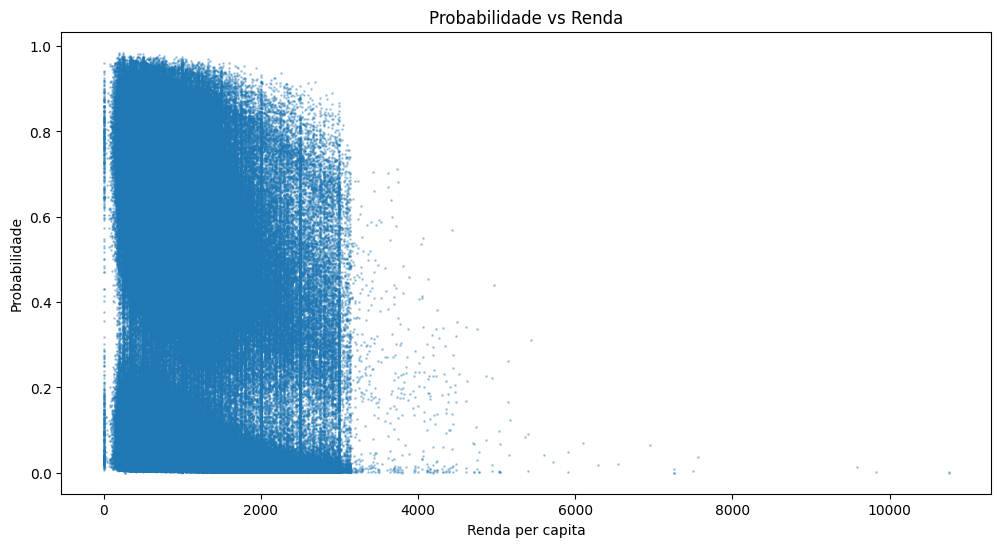

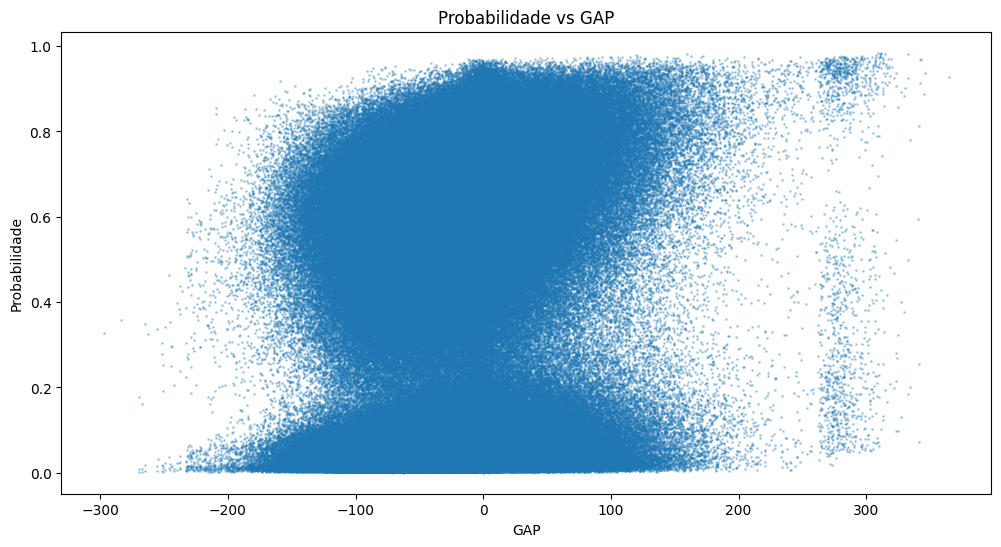

815,609 registros processados.
Top 20 variáveis mais importantes:


,Variável,Coeficiente,Impacto_Absoluto
4,opcao_curso_3,-1.766607,1.766607
3,opcao_curso_2,-1.397291,1.397291
0,renda_per_capita,-0.428116,0.428116
20,"subarea_conhecimento_DIREITO, COMÉRCIO EXTERIO...",0.422674,0.422674
38,"subarea_conhecimento_ODONTOLOGIA, QUIROPRAXIA,...",0.412684,0.412684
21,"subarea_conhecimento_ENFERMAGEM, FISIOTERAPIA,...",0.404345,0.404345
22,subarea_conhecimento_ENGENHARIA CIVIL E AMBIEN...,0.258963,0.258963
53,natureza_juridica_mantenedora_PRIVADA SEM FINS...,0.249922,0.249922
52,natureza_juridica_mantenedora_PRIVADA COM FINS...,0.228877,0.228877
1,gap,0.223978,0.223978


ROC-AUC: 0.8441
Acurácia (threshold ótimo): 0.6803
Threshold ótimo: 0.4887


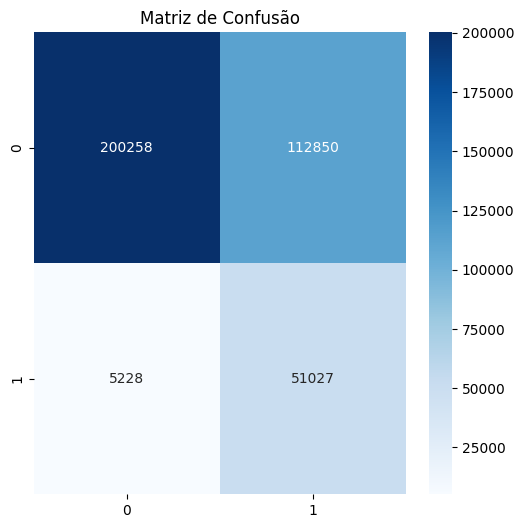

In [ ]:
import sys
import pandas as pd
from src.staging import staging_fies, staging_inep
from src.transform_layer_1 import transform_inscritos, transform_ofertas, transform_inep, verificar_colunas_inep
from src.transform_layer_2 import tratar_nans_cine_inscritos, tratar_nans_cine_ofertas
from src.trasnform_layer_3 import processar_modalidades_e_peneira
from src.load import load_inscritos,load_ofertas,auditoria_inscritos_carregados,auditoria_ofertas_carregadas,exportar_para_sqlite
from src.analise_001 import gerar_dataset_candidatos_unicos_por_Prioridade_inicial
from src.analise_002 import eda_gerar_dataset_com_varias_analises
from src.analise_003 import eda_gerar_funil_de_selecao_6_etapas
from src.analise_004 import analise_fuga_cerebros_de_regioes
from src.analise_005 import verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional
from src.analise_006 import gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados
from src.analise_007 import orquestrador_inicial_inscritos, orquestrador_ja_rodado_inscritos
from src.analise_008 import orquestrador_inicial_candidatos, orquestrador_ja_rodado_candidatos
from src.analise_009 import orquestrador_inicial_inscritos_nove, orquestrador_ja_rodado_inscritos_nove





comando = 'analise'
etapa = '9'

# --- CAMADA: STAGING ---
if comando == "staging":
    staging_fies()
    staging_inep()

# --- CAMADA: TRANSFORM ---
elif comando == "transform":

    if etapa == "1":
        transform_inep()
    elif etapa == "2":
        transform_inscritos()
    elif etapa == "3":
        transform_ofertas()
    elif etapa == "4":
        verificar_colunas_inep()
    elif etapa == "5":
        tratar_nans_cine_inscritos()
    elif etapa == "6":
        tratar_nans_cine_ofertas()
    elif etapa == "7":
        processar_modalidades_e_peneira()
    elif etapa == "all":
        transform_inep()
        transform_inscritos()
        transform_ofertas()
        verificar_colunas_inep()
        tratar_nans_cine_inscritos()
        tratar_nans_cine_ofertas()
        processar_modalidades_e_peneira()

elif comando == "load":

    load_inscritos()
    load_ofertas()
    auditoria_inscritos_carregados()
    auditoria_ofertas_carregadas()
    exportar_para_sqlite()

elif comando == 'analise':

    if etapa == "1":
        gerar_dataset_candidatos_unicos_por_Prioridade_inicial()

    elif etapa == "2":
        eda_gerar_dataset_com_varias_analises()

    elif etapa == "3":
        eda_gerar_funil_de_selecao_6_etapas()

    elif etapa == "4":
        analise_fuga_cerebros_de_regioes()

    elif etapa == "5":
        verificar_qtde_inscritos_por_ano_e_semestre_nacional_e_regional()

    elif etapa == "6":
        gerar_dataset_e_grafico_heatmap_quem_sao_os_inscritos_contratados()

    elif etapa == "7":
        orquestrador_inicial_inscritos()
    
    elif etapa == "7.1":
        orquestrador_ja_rodado_inscritos()

    elif etapa == "8":
        orquestrador_inicial_candidatos()
    
    elif etapa == "8.1":
        orquestrador_ja_rodado_candidatos()

    elif etapa == "9":
        orquestrador_inicial_inscritos_nove()
    
    elif etapa == "9.1":
        orquestrador_ja_rodado_inscritos_nove()